# 📊 Notebook 04 — Scorecard y Análisis de Variables

> **Entrada** : `splits.pkl` + `modelo_final.pt` + `loan_procesado.parquet`  
> **Salida** : `scorecard.pkl` + `distribucion_scores.csv`

## Contenido
1. Carga del modelo final y los datos
2. Conversión de probabilidades a puntaje (scorecard)
3. Distribución de puntajes por clase
4. Análisis de variables con SHAP
5. ¿Qué hace más riesgosa a una persona?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Manipulación de datos ────────────────────────────────────────────────────
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn

# ── SHAP ─────────────────────────────────────────────────────────────────────
import shap

# ── Configuration ────────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 80
sns.set_theme(style='whitegrid', font_scale=1.1)

PROYECTO_PATH = '/content/drive/MyDrive/riesgo_credito'
DATA_PATH     = os.path.join(PROYECTO_PATH, 'data')
FIGURES_PATH  = os.path.join(PROYECTO_PATH, 'figures')
OUTPUT_PATH   = os.path.join(PROYECTO_PATH, 'outputs')
MODELS_PATH   = os.path.join(PROYECTO_PATH, 'models')

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'✅ Librerías importadas | Dispositivo : {DEVICE}')

Mounted at /content/drive
✅ Librerías importadas | Dispositivo : cpu


---
## 1. Carga del modelo final y los datos

Cargamos los tres archivos producidos en los notebooks anteriores :
- `splits.pkl` — los datos de train/val/test preprocesados
- `modelo_final.pt` — los pesos del mejor modelo (Red Neuronal C)
- `loan_procesado.parquet` — el dataset filtrado antes del rééchantillonnage,
  necesario para calcular la distribución de scores sobre la población real

In [ ]:
# La arquitectura debe redefinirse exactamente igual que en el Notebook 03
# para poder cargar los pesos guardados
class RedNeuronal(nn.Module):
    def __init__(self, n_entrada, capas, dropout):
        super(RedNeuronal, self).__init__()
        bloques = []
        n_anterior = n_entrada
        for n_neuronas in capas:
            bloques.append(nn.Linear(n_anterior, n_neuronas))
            bloques.append(nn.ReLU())
            bloques.append(nn.Dropout(dropout))
            n_anterior = n_neuronas
        bloques.append(nn.Linear(n_anterior, 1))
        bloques.append(nn.Sigmoid())
        self.red = nn.Sequential(*bloques)

    def forward(self, x):
        return self.red(x)


# Carga de los splits
splits  = joblib.load(os.path.join(OUTPUT_PATH, 'splits.pkl'))
X_train = splits['X_train']
y_train = splits['y_train']
X_val   = splits['X_val']
y_val   = splits['y_val']
X_test  = splits['X_test']
y_test  = splits['y_test']

N_ENTRADA = X_train.shape[1]   # 14

# Carga del modelo final (Modelo C : 128 → 64 → 32)
modelo = RedNeuronal(N_ENTRADA, capas=[128, 64, 32], dropout=0.4)
modelo.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, 'modelo_final.pt'),
               map_location=DEVICE)
)
modelo.eval()
modelo.to(DEVICE)

# Carga del dataset procesado (población real sin rééchantillonnage)
df_poblacion = pd.read_parquet(os.path.join(DATA_PATH, 'loan_procesado.parquet'))

print(f'✅ Modelo cargado     : Red Neuronal C (128 → 64 → 32)')
print(f'✅ Splits cargados    : train {X_train.shape} | test {X_test.shape}')
print(f'✅ Población cargada  : {df_poblacion.shape[0]:,} observaciones')

✅ Modelo cargado     : Red Neuronal C (128 → 64 → 32)
✅ Splits cargados    : train (82346, 14) | test (17646, 14)
✅ Población cargada  : 268,530 observaciones


---
## 2. Conversión de probabilidades a puntaje (Scorecard)

### ¿Por qué convertir probabilidades a puntaje?

Una probabilidad de 0.23 es difícil de comunicar a un cliente o a un analista
de crédito. Un puntaje de 720 sobre 850 es inmediatamente comprensible.

La conversión sigue la metodología estándar de escalado de scorecards
(Siddiqi, 2006), basada en dos parámetros de negocio :

- **PDO** (*Points to Double the Odds*) : cuántos puntos representan
  duplicar la razón buenos/malos. Valor estándar : **50 puntos**.
- **Odds objetivo** : la razón buenos/malos en el puntaje de referencia.
  Usaremos **1:1** (odds = 1) en el puntaje base de **600**.

La fórmula de escalado es :

> **Score = Offset + Factor × ln(odds)**
>
> donde **odds = (1 − p) / p** y **p** es la probabilidad de incumplimiento

Un puntaje más alto indica **menor riesgo** — consistente con las escalas
de scoring comerciales como FICO (300–850).

In [ ]:
def predecir_probabilidades(modelo, X):
    """Retorna las probabilidades de incumplimiento para un conjunto X."""
    modelo.eval()
    X_t = torch.FloatTensor(
        X.values if hasattr(X, 'values') else X
    ).to(DEVICE)
    with torch.no_grad():
        probas = modelo(X_t).cpu().numpy().flatten()
    return probas


def probabilidad_a_score(p, pdo=50, odds_objetivo=1, score_base=600):
    """
    Convierte una probabilidad de incumplimiento en un puntaje de scorecard.

    Parámetros :
    - p             : probabilidad de incumplimiento (entre 0 y 1)
    - pdo           : puntos para duplicar los odds (estándar = 50)
    - odds_objetivo : odds buenos/malos en score_base (estándar = 1)
    - score_base    : puntaje de referencia (estándar = 600)

    Retorna : puntaje entero (mayor = menor riesgo)
    """
    factor = pdo / np.log(2)
    offset = score_base - factor * np.log(odds_objetivo)

    # Evitar log(0) : clipear probabilidades en [0.001, 0.999]
    p_clip = np.clip(p, 0.001, 0.999)
    odds   = (1 - p_clip) / p_clip
    score  = offset + factor * np.log(odds)

    return np.round(score).astype(int)


# Cálculo de probabilidades y scores sobre el test set
probas_test = predecir_probabilidades(modelo, X_test)
scores_test = probabilidad_a_score(probas_test)

print('✅ Scores calculados sobre el conjunto de test :')
print(f'   Probabilidad media  : {probas_test.mean():.4f}')
print(f'   Score mínimo        : {scores_test.min()}')
print(f'   Score máximo        : {scores_test.max()}')
print(f'   Score medio         : {scores_test.mean():.1f}')
print(f'   Score mediano       : {np.median(scores_test):.1f}')

✅ Scores calculados sobre el conjunto de test :
   Probabilidad media  : 0.4877
   Score mínimo        : 470
   Score máximo        : 823
   Score medio         : 605.1
   Score mediano       : 600.0


In [ ]:
# ── Recalibración de Platt — corrección del sesgo por undersampling ──────────
# El modelo fue entrenado sobre un dataset balanceado 50/50 (undersampling).
# La distribución real del dataset original es 21.9% default / 78.1% buenos pagadores.
prior_train = 0.50
prior_real  = 0.219

def calibrar_probabilidad(prob_raw):
    prob_raw = np.clip(prob_raw, 1e-6, 1 - 1e-6)
    odds_raw = prob_raw / (1 - prob_raw)
    odds_cal = odds_raw * (prior_real / (1 - prior_real)) / (prior_train / (1 - prior_train))
    return odds_cal / (1 + odds_cal)

print(f"Probabilidad media ANTES de calibración : {probas_test.mean():.4f}")
probas_test = calibrar_probabilidad(probas_test)
scores_test = probabilidad_a_score(probas_test)
print(f"Probabilidad media DESPUÉS de calibración: {probas_test.mean():.4f}")
print(f"Esperado tras calibración                : ~{prior_real:.4f}")

---
## 3. Distribución de puntajes por clase

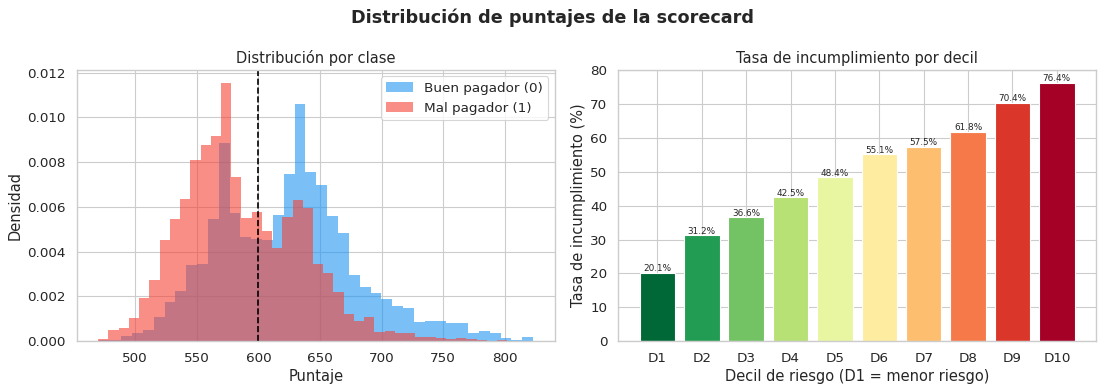

📊 Figura guardada en figures/


In [ ]:
df_scores = pd.DataFrame({
    'score'  : scores_test,
    'proba'  : probas_test,
    'default': y_test.values if hasattr(y_test, 'values') else y_test
})

PALETA = {0: '#2196F3', 1: '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de puntajes de la scorecard', fontweight='bold')

# ── Histograma superpuesto por clase ────────────────────────────────────────
for clase, color in PALETA.items():
    datos = df_scores.loc[df_scores['default'] == clase, 'score']
    etiqueta = 'Buen pagador (0)' if clase == 0 else 'Mal pagador (1)'
    axes[0].hist(datos, bins=40, alpha=0.6, color=color,
                 label=etiqueta, density=True, edgecolor='none')

axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución por clase')
axes[0].legend()
axes[0].axvline(df_scores['score'].median(), color='black',
                linestyle='--', linewidth=1.5, label='Mediana global')

# ── Score medio por decil de probabilidad ───────────────────────────────────
df_scores['decil'] = pd.qcut(df_scores['proba'], q=10,
                              labels=[f'D{i}' for i in range(1, 11)])
tasa_por_decil = df_scores.groupby('decil')['default'].mean() * 100
score_por_decil = df_scores.groupby('decil')['score'].mean()

color_decil = plt.cm.RdYlGn_r(
    np.linspace(0, 1, len(tasa_por_decil))
)
bars = axes[1].bar(tasa_por_decil.index, tasa_por_decil.values,
                   color=color_decil, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=8)
axes[1].set_xlabel('Decil de riesgo (D1 = menor riesgo)')
axes[1].set_ylabel('Tasa de incumplimiento (%)')
axes[1].set_title('Tasa de incumplimiento por decil')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '10_distribucion_scores.png'),
            bbox_inches='tight')
plt.show()
print('📊 Figura guardada en figures/')

---
## 4. Análisis de variables con SHAP

SHAP (*SHapley Additive exPlanations*) es una técnica de interpretabilidad
basada en la teoría de juegos cooperativos. Para cada predicción, calcula
la contribución de cada variable al valor final — respondiendo a la pregunta :

> *¿Cuánto contribuyó la variable X a que este cliente tenga una
> probabilidad de incumplimiento de Y%?*

Usamos un **KernelExplainer** de SHAP, compatible con cualquier modelo
incluyendo redes neuronales. Para reducir el tiempo de cálculo, calculamos
los valores SHAP sobre una muestra representativa del conjunto de test.

In [ ]:
# Muestra representativa para SHAP (200 observaciones — equilibrio velocidad/precisión)
np.random.seed(SEED)
idx_muestra = np.random.choice(len(X_test), size=200, replace=False)

X_test_arr  = X_test.values if hasattr(X_test, 'values') else X_test
X_muestra   = X_test_arr[idx_muestra]
nombres_vars = (X_test.columns.tolist()
                if hasattr(X_test, 'columns')
                else [f'var_{i}' for i in range(X_test_arr.shape[1])])

# Fonction wrapper pour SHAP
def predecir_para_shap(X_arr):
    """Wrapper que retorna las probabilidades de incumplimiento."""
    modelo.eval()
    X_t = torch.FloatTensor(X_arr).to(DEVICE)
    with torch.no_grad():
        return modelo(X_t).cpu().numpy().flatten()

# Fondo de referencia : medias del train (más rápido que KMeans)
fondo = X_test_arr[:50]

print('🔄 Calculando valores SHAP (puede tomar 1-2 minutos)...')
explainer   = shap.KernelExplainer(predecir_para_shap, fondo)
shap_values = explainer.shap_values(X_muestra, nsamples=100)

print('✅ Valores SHAP calculados')
print(f'   Shape : {np.array(shap_values).shape}')

🔄 Calculando valores SHAP (puede tomar 1-2 minutos)...


  0%|          | 0/200 [00:00<?, ?it/s]

✅ Valores SHAP calculados
   Shape : (200, 14)


### 4.1 Importancia global de variables

El gráfico siguiente muestra el impacto promedio de cada variable sobre
las predicciones del modelo. Un valor SHAP alto (en valor absoluto) indica
que la variable tiene una influencia importante sobre la probabilidad de
incumplimiento predicha.

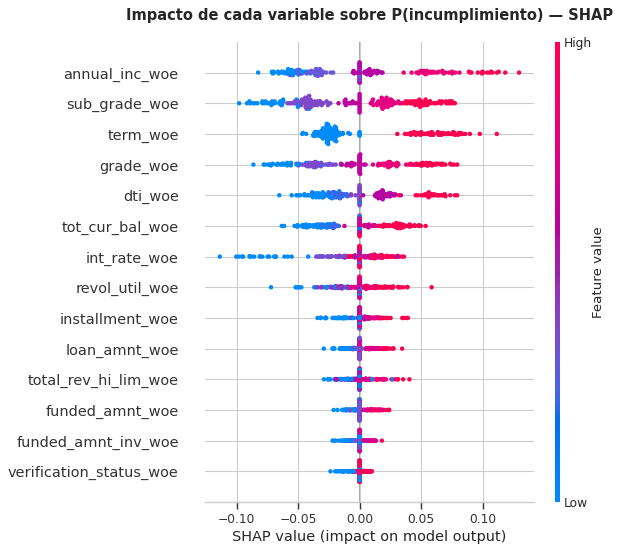

📊 Figura guardada en figures/


In [ ]:
# Summary plot — impacto de cada variable sobre todas las predicciones
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_muestra,
    feature_names=nombres_vars,
    show=False,
    plot_type='dot'
)
plt.title('Impacto de cada variable sobre P(incumplimiento) — SHAP',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '11_shap_summary.png'),
            bbox_inches='tight')
plt.show()
print('📊 Figura guardada en figures/')

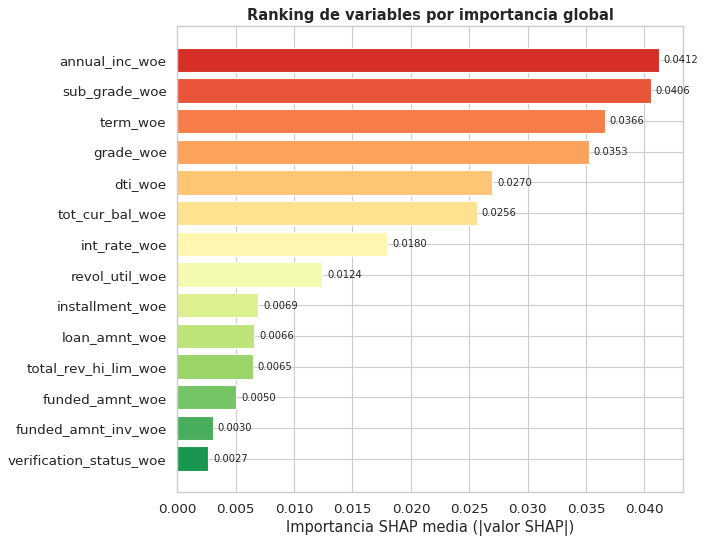


📊 Top 5 variables más importantes :
      variable  importancia
annual_inc_woe       0.0412
 sub_grade_woe       0.0406
      term_woe       0.0366
     grade_woe       0.0353
       dti_woe       0.0270


In [ ]:
# Importancia media absoluta — ranking de variables
importancia_media = np.abs(shap_values).mean(axis=0)
importancia_df = pd.DataFrame({
    'variable'   : nombres_vars,
    'importancia': importancia_media
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(importancia_df) * 0.5)))

colores = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(importancia_df))
)
bars = ax.barh(importancia_df['variable'],
               importancia_df['importancia'],
               color=colores, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + importancia_df['importancia'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=9)

ax.set_xlabel('Importancia SHAP media (|valor SHAP|)')
ax.set_title('Ranking de variables por importancia global', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '12_shap_importancia.png'),
            bbox_inches='tight')
plt.show()

print('\n📊 Top 5 variables más importantes :')
print(importancia_df.tail(5)[['variable', 'importancia']]
      .sort_values('importancia', ascending=False).to_string(index=False))

---
## 5. ¿Qué hace más riesgosa a una persona?

Más allá de la importancia global, analizamos la **dirección** del impacto
de cada variable : ¿un valor alto de `int_rate` aumenta o disminuye
el riesgo? ¿Cómo influye el grado de crédito?

Para esto usamos los gráficos de dependencia SHAP, que muestran cómo
varía el valor SHAP de una variable en función de su valor original.
Un valor SHAP positivo significa que la variable **aumenta** la probabilidad
de incumplimiento predicha ; un valor negativo la **disminuye**.

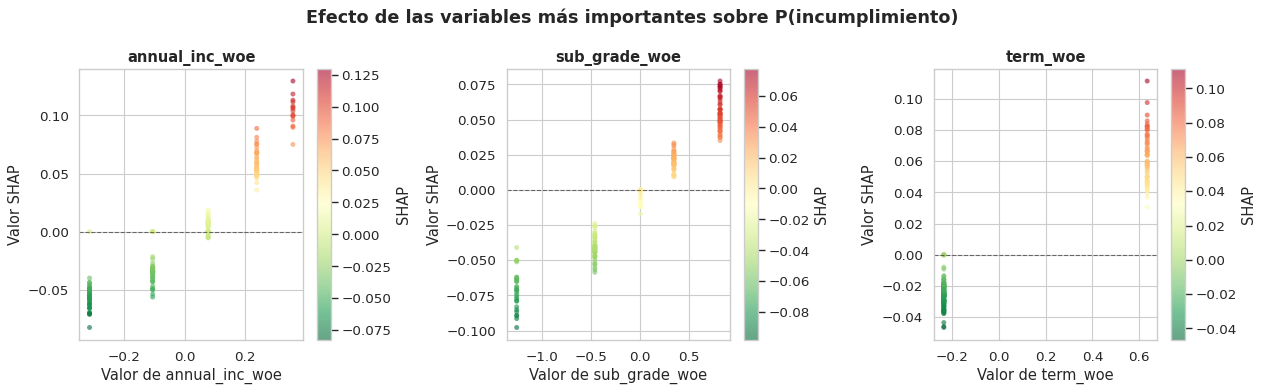

📊 Figura guardada en figures/


In [ ]:
# Top 3 variables más importantes
top3_vars = importancia_df.tail(3)['variable'].tolist()[::-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Efecto de las variables más importantes sobre P(incumplimiento)',
             fontweight='bold')

for ax, var in zip(axes, top3_vars):
    if var in nombres_vars:
        idx_var = nombres_vars.index(var)
        valores_var  = X_muestra[:, idx_var]
        valores_shap = shap_values[:, idx_var]

        sc = ax.scatter(valores_var, valores_shap,
                        c=valores_shap, cmap='RdYlGn_r',
                        alpha=0.6, s=20, edgecolors='none')
        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel(f'Valor de {var}')
        ax.set_ylabel('Valor SHAP')
        ax.set_title(var, fontweight='bold')
        plt.colorbar(sc, ax=ax, label='SHAP')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '13_shap_dependencia.png'),
            bbox_inches='tight')
plt.show()
print('📊 Figura guardada en figures/')

---
## 6. Perfil de riesgo — ¿Qué caracteriza a un mal pagador?

A partir del análisis SHAP podemos construir el perfil típico de un
cliente de alto riesgo en este dataset. Este análisis responde directamente
a la pregunta del proyecto : *¿qué variables hacen más riesgosa a una persona?*

📊 Perfil comparativo (Variables Numéricas) — Top 5 importantes :


,Buen pagador (0),Mal pagador (1),Diferencia (%)
annual_inc,74142.4452,66149.7887,-10.8000
dti,16.1199,18.6574,15.7000


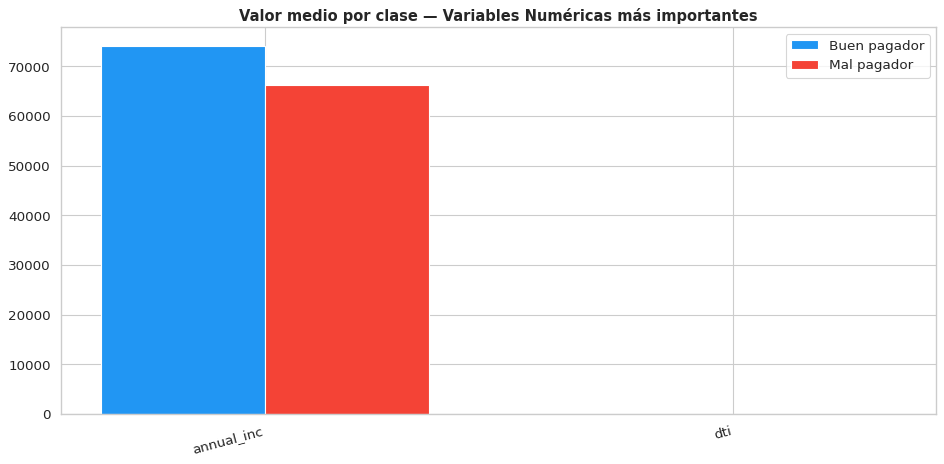

📊 Figura guardada en figures/


In [ ]:
# 1. Obtener el top 5 de las variables desde importancia_df
top5_vars_raw = importancia_df.tail(5)['variable'].tolist()[::-1]

# 2. Limpiar los nombres (quitar '_woe') para coincidir con df_poblacion
mapping_vars = {v: v.replace('_woe', '') for v in top5_vars_raw}
top5_vars_clean = [mapping_vars[v] for v in top5_vars_raw if mapping_vars[v] in df_poblacion.columns]

# 3. Filtrar solo las variables que son numéricas para evitar el error de la media
vars_numericas = df_poblacion[top5_vars_clean].select_dtypes(include=[np.number]).columns.tolist()

if len(vars_numericas) > 0:
    # Cálculo de las medias por clase (0: Buen pagador, 1: Mal pagador)
    resumen_perfil = df_poblacion.groupby('default')[vars_numericas].mean().T
    resumen_perfil.columns = ['Buen pagador (0)', 'Mal pagador (1)']

    # Cálculo de la diferencia porcentual
    resumen_perfil['Diferencia (%)'] = (
        (resumen_perfil['Mal pagador (1)'] - resumen_perfil['Buen pagador (0)'])
        / resumen_perfil['Buen pagador (0)'].abs() * 100
    ).round(1)

    print('📊 Perfil comparativo (Variables Numéricas) — Top 5 importantes :')
    display(resumen_perfil)

    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))
    x      = np.arange(len(vars_numericas))
    ancho  = 0.35

    ax.bar(x - ancho/2, resumen_perfil['Buen pagador (0)'], ancho,
           label='Buen pagador', color='#2196F3', edgecolor='white')
    ax.bar(x + ancho/2, resumen_perfil['Mal pagador (1)'], ancho,
           label='Mal pagador', color='#F44336', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(vars_numericas, rotation=15, ha='right')
    ax.set_title('Valor medio por clase — Variables Numéricas más importantes', fontweight='bold')
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, '14_perfil_riesgo.png'), bbox_inches='tight')
    plt.show()
    print('📊 Figura guardada en figures/')
else:
    print('⚠️ No se encontraron variables numéricas correspondientes en el Top 5 para promediar.')

In [ ]:
print(top5_vars)

[]


---
## 7. Guardado de resultados

In [ ]:
# Sauvegarde de la fonction de scoring et des résultats
joblib.dump({
    'pdo'          : 50,
    'odds_objetivo': 1,
    'score_base'   : 600,
    'n_entrada'    : N_ENTRADA,
    'capas'        : [128, 64, 32],
    'dropout'      : 0.4
}, os.path.join(OUTPUT_PATH, 'scorecard_params.pkl'))

# Distribution des scores sur la population
df_scores.to_csv(
    os.path.join(OUTPUT_PATH, 'distribucion_scores.csv'),
    index=False
)

# Importances SHAP
importancia_df.sort_values('importancia', ascending=False).to_csv(
    os.path.join(OUTPUT_PATH, 'importancia_variables.csv'),
    index=False
)

print('✅ Archivos guardados :')
print(f'   scorecard_params.pkl      → {OUTPUT_PATH}')
print(f'   distribucion_scores.csv   → {OUTPUT_PATH}')
print(f'   importancia_variables.csv → {OUTPUT_PATH}')

✅ Archivos guardados :
   scorecard_params.pkl      → /content/drive/MyDrive/riesgo_credito/outputs
   distribucion_scores.csv   → /content/drive/MyDrive/riesgo_credito/outputs
   importancia_variables.csv → /content/drive/MyDrive/riesgo_credito/outputs


---
## ✅ Resumen — Lo que hicimos en este notebook

1. **Cargamos** el modelo final y los datos preprocesados
2. **Convertimos** las probabilidades en puntajes interpretables (escala 300–850)
   usando la metodología estándar PDO de Siddiqi (2006)
3. **Visualizamos** la distribución de puntajes por clase y por decil de riesgo
4. **Calculamos valores SHAP** para interpretar el impacto de cada variable
5. **Identificamos** las variables que más aumentan el riesgo de incumplimiento
6. **Construimos** el perfil comparativo entre buenos y malos pagadores

## 📌 Variables que hacen más riesgosa a una persona

> Completa esta sección con los hallazgos del análisis SHAP una vez
> ejecutado el notebook. Por ejemplo :
> - ¿Una tasa de interés alta aumenta el riesgo? ¿A partir de qué umbral?
> - ¿El grado de crédito bajo (G, F) es el factor más determinante?
> - ¿El DTI alto contribuye más que el historial de pagos?

## ➡️ Siguiente paso — Notebook 05 : Aplicación web (Streamlit)

En el próximo notebook construiremos la interfaz que permite a un usuario
ingresar sus características y obtener su scorecard en tiempo real.